In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import joblib

import warnings
warnings.filterwarnings('ignore')

##  Load Dataset

In [6]:
df = pd.read_csv("pseudo_facebook.csv")

print(df.shape)

(99003, 15)


In [7]:
df.head()

,userid,age,dob_day,dob_year,dob_month,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
0,2094382,14,19,1999,11,male,266.0,0,0,0,0,0,0,0,0
1,1192601,14,2,1999,11,female,6.0,0,0,0,0,0,0,0,0
2,2083884,14,16,1999,11,male,13.0,0,0,0,0,0,0,0,0
3,1203168,14,25,1999,12,female,93.0,0,0,0,0,0,0,0,0
4,1733186,14,4,1999,12,male,82.0,0,0,0,0,0,0,0,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99003 entries, 0 to 99002
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   userid                 99003 non-null  int64  
 1   age                    99003 non-null  int64  
 2   dob_day                99003 non-null  int64  
 3   dob_year               99003 non-null  int64  
 4   dob_month              99003 non-null  int64  
 5   gender                 98828 non-null  str    
 6   tenure                 99001 non-null  float64
 7   friend_count           99003 non-null  int64  
 8   friendships_initiated  99003 non-null  int64  
 9   likes                  99003 non-null  int64  
 10  likes_received         99003 non-null  int64  
 11  mobile_likes           99003 non-null  int64  
 12  mobile_likes_received  99003 non-null  int64  
 13  www_likes              99003 non-null  int64  
 14  www_likes_received     99003 non-null  int64  
dtypes: float64(1)

In [9]:
df.describe()


,userid,age,dob_day,dob_year,dob_month,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received
count,9.900300e+04,99003.000000,99003.000000,99003.000000,99003.000000,99001.000000,99003.000000,99003.000000,99003.000000,99003.000000,99003.000000,99003.000000,99003.000000,99003.000000
mean,1.597045e+06,37.280224,14.530408,1975.719776,6.283365,537.887375,196.350787,107.452471,156.078785,142.689363,106.116300,84.120491,49.962425,58.568831
std,3.440592e+05,22.589748,9.015606,22.589748,3.529672,457.649874,387.304229,188.786951,572.280681,1387.919613,445.252985,839.889444,285.560152,601.416348
min,1.000008e+06,13.000000,1.000000,1900.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.298806e+06,20.000000,7.000000,1963.000000,3.000000,226.000000,31.000000,17.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.596148e+06,28.000000,14.000000,1985.000000,6.000000,412.000000,82.000000,46.000000,11.000000,8.000000,4.000000,4.000000,0.000000,2.000000
75%,1.895744e+06,50.000000,22.000000,1993.000000,9.000000,675.000000,206.000000,117.000000,81.000000,59.000000,46.000000,33.000000,7.000000,20.000000
max,2.193542e+06,113.000000,31.000000,2000.000000,12.000000,3139.000000,4923.000000,4144.000000,25111.000000,261197.000000,25111.000000,138561.000000,14865.000000,129953.000000


In [10]:
df.isnull().sum()

userid                     0
age                        0
dob_day                    0
dob_year                   0
dob_month                  0
gender                   175
tenure                     2
friend_count               0
friendships_initiated      0
likes                      0
likes_received             0
mobile_likes               0
mobile_likes_received      0
www_likes                  0
www_likes_received         0
dtype: int64

##  Data Cleening 

In [11]:
# Missing values

df['gender'].fillna(df['gender'].mode()[0], inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


## Remove Duplicates

In [12]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


## Check Again

In [13]:
df.isnull().sum()

userid                     0
age                        0
dob_day                    0
dob_year                   0
dob_month                  0
gender                   175
tenure                     2
friend_count               0
friendships_initiated      0
likes                      0
likes_received             0
mobile_likes               0
mobile_likes_received      0
www_likes                  0
www_likes_received         0
dtype: int64

In [28]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['tenure'] = df['tenure'].fillna(df['tenure'].median())

print(df.isnull().sum().sum())

0


In [14]:
df['gender'] = df['gender'].map({
    'male':0,
    'female':1
})

## Exploratory Data Analysis(EDA)

### Age Distribution

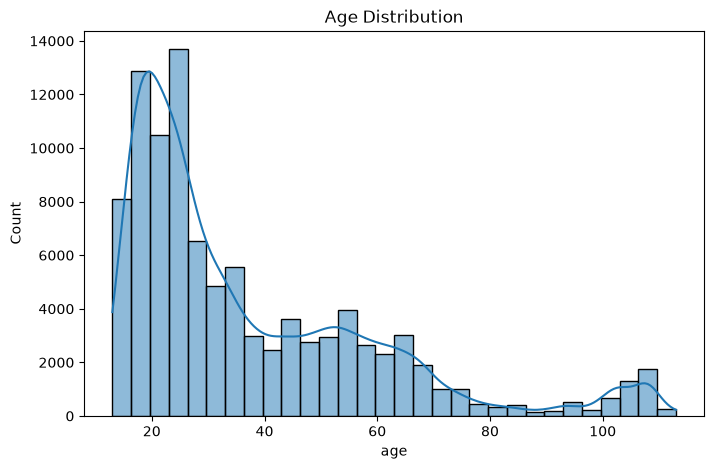

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

##  Age Distribution – Key Insights
- Majority of users are between 18–30 years old, indicating Facebook is most popular among young adults.
- The highest concentration of users is around 20–25 years, where the distribution peaks.
- User count gradually decreases as age increases, showing fewer older users on the platform.
- The distribution is right-skewed (positively skewed), with a long tail extending toward higher ages.
- A smaller group of users exists between 45–65 years, representing mature and long-term users.
- Very high ages (100+) appear as potential outliers or data quality issues and may require further investigation.

### Gender Count

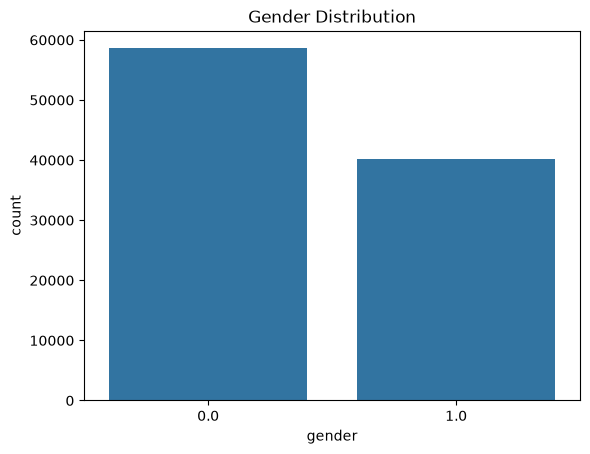

In [16]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

##  Gender Distribution – Key Insights
- Gender 0 has the highest number of users, with approximately 58K users.
- Gender 1 accounts for around 40K users.
- The dataset shows a moderate imbalance, where Gender 0 represents a larger share of the user base.
- Gender 0 users are roughly 1.5 times more numerous than Gender 1 users.
- Since gender is encoded as 0 and 1, it is important to verify which value represents Male and Female before drawing demographic 

### Friend Count Distribution

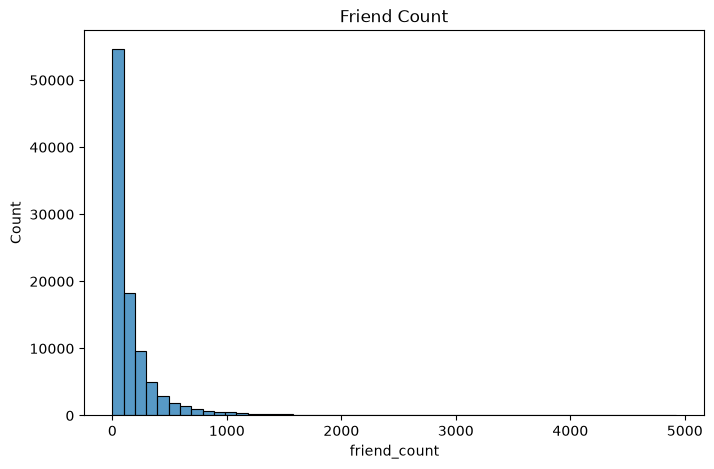

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['friend_count'], bins=50)
plt.title("Friend Count")
plt.show()

## Friend Count Distribution – Key Insights
- Most users have a low to moderate number of friends, with the highest concentration below 200 friends.
- The distribution is heavily right-skewed, meaning a small number of users have exceptionally high friend counts.
- A few users have 1,000+ friends, indicating highly connected or influential users.
- Extreme values reaching several thousand friends appear as outliers and may represent celebrities, influencers, or power users.
- The majority of Facebook users maintain relatively smaller social networks compared to these highly connected users.

### Like Distribution

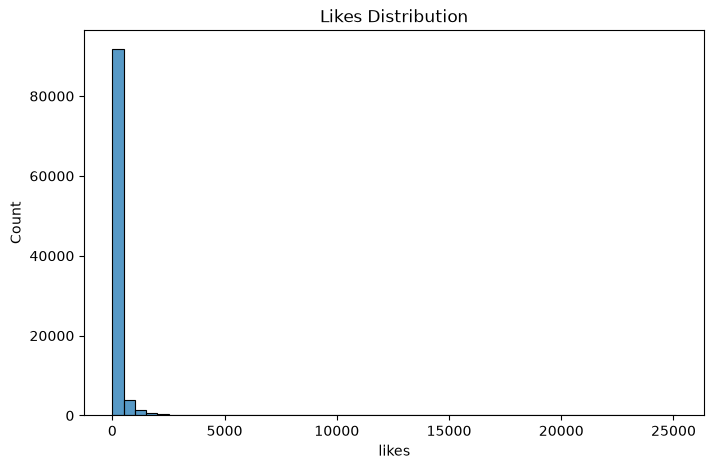

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['likes'], bins=50)
plt.title("Likes Distribution")
plt.show()

## Likes Distribution – Key Insights
- The majority of users have very low like activity, with most values concentrated near zero.
- The distribution is heavily right-skewed, indicating that only a small number of users generate a large number of likes.
- A few users have extremely high like counts, creating a long tail in the distribution.
- These very high values can be considered outliers and may represent highly active or influential users.
- User engagement through likes is unevenly distributed, with a small percentage of users contributing a significant portion of total likes.

### Friend Count vs LIkes

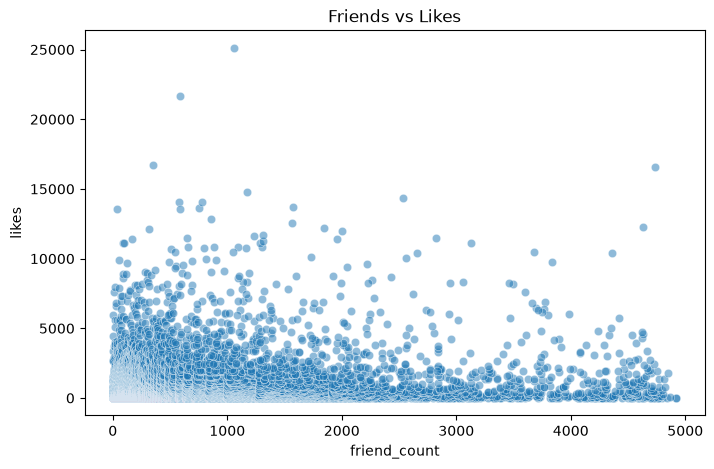

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='friend_count',
    y='likes',
    data=df,
    alpha=0.5
)

plt.title("Friends vs Likes")
plt.show()

## Friend Count vs Likes – Key Insights
- There is a weak positive relationship between friend count and likes; users with more friends tend to receive more likes, but the relationship is not very strong.
- Most users are concentrated in the lower-left area, indicating relatively low friend counts and low like activity.
- Several users receive very high likes despite having a moderate number of friends, suggesting that engagement depends on more than just friend count.
- The chart contains a number of outliers with exceptionally high likes and/or friend counts.
- The wide spread of points shows that users with similar friend counts can have very different levels of engagement.

###  Correlation Heatmap

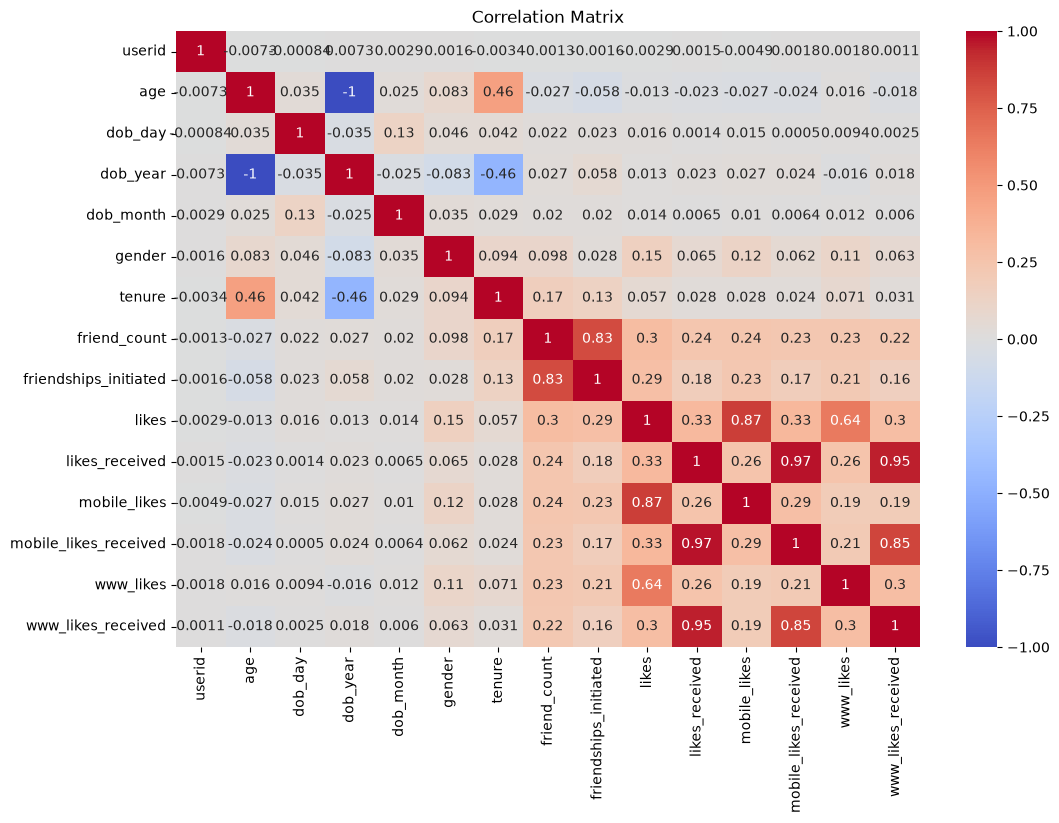

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## Correlation Heatmap – Key Insights
- Friend Count and Friendships Initiated show a strong positive correlation (0.83), indicating users with more friends tend to initiate more friendships.
- Likes and Mobile Likes have a very strong correlation (0.87), suggesting most user engagement occurs through mobile devices.
- Age and Tenure have a moderate positive correlation (0.46), meaning older users generally have been on Facebook longer.
- Age and Birth Year have a perfect negative correlation (-1.00), which is expected because age is calculated from birth year.
- Likes show a moderate positive relationship with Friend Count (0.30) and Friendships Initiated (0.29).
- Most other correlations are relatively low, indicating that many user behaviors are influenced by multiple factors rather than a single variable.

### Select Features for Clustering

In [21]:
features = [

'age',
'tenure',
'friend_count',
'friendships_initiated',
'likes',
'likes_received',
'mobile_likes',
'mobile_likes_received',
'www_likes',
'www_likes_received'

]

X = df[features]

### Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
print(np.isnan(X_scaled).sum())

2


### Elbow methode

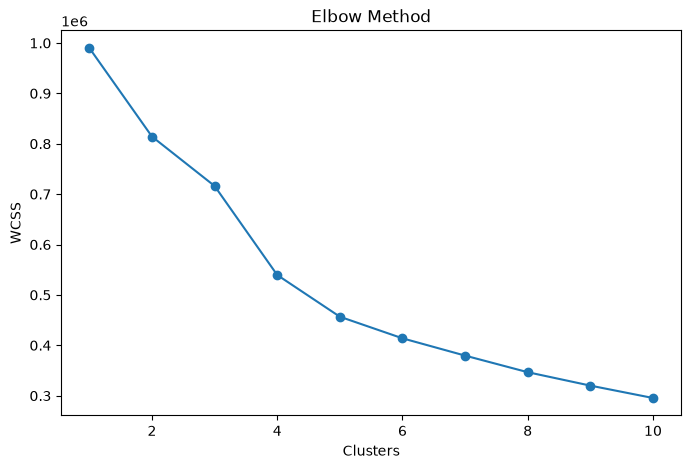

In [24]:
wcss = []

# Handle missing values in X_scaled before clustering
# Option 1: Remove rows with NaN values
# X_scaled_clean = X_scaled.dropna()

# Option 2: Impute missing values with mean (recommended approach)
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'
X_scaled_clean = imputer.fit_transform(X_scaled)

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    # Use the cleaned data without NaN values
    kmeans.fit(X_scaled_clean)
    
    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

## Elbow Method – Key Insights
- The WCSS (Within-Cluster Sum of Squares) decreases sharply as the number of clusters increases from 1 to 5.
- After K = 5, the curve starts to flatten, meaning additional clusters provide only small improvements.
- The elbow point appears at K = 5, indicating the optimal number of clusters for segmentation.
- Choosing more than 5 clusters may increase complexity without significantly improving cluster quality.
- Therefore, 5 clusters provide the best balance between simplicity and segmentation accuracy.

### KMeans Clustering

In [25]:
imputer = SimpleImputer(strategy='mean')  # You can also use 'median' or 'most_frequent'
X_scaled_clean = imputer.fit_transform(X_scaled)

# Now apply KMeans clustering
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    X_scaled_clean  # Use the cleaned data instead of X_scaled
)

df['Cluster'] = clusters

df.head()

,userid,age,dob_day,dob_year,dob_month,gender,tenure,friend_count,friendships_initiated,likes,likes_received,mobile_likes,mobile_likes_received,www_likes,www_likes_received,Cluster
0,2094382,14,19,1999,11,0.0,266.0,0,0,0,0,0,0,0,0,0
1,1192601,14,2,1999,11,1.0,6.0,0,0,0,0,0,0,0,0,0
2,2083884,14,16,1999,11,0.0,13.0,0,0,0,0,0,0,0,0,0
3,1203168,14,25,1999,12,1.0,93.0,0,0,0,0,0,0,0,0,0
4,1733186,14,4,1999,12,0.0,82.0,0,0,0,0,0,0,0,0,0


### Cluster Distribution

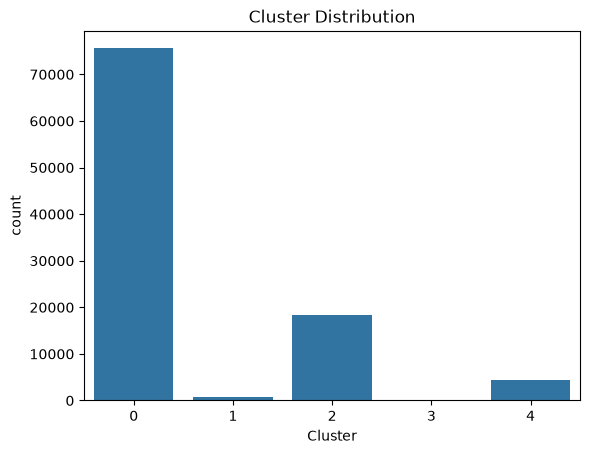

In [26]:
sns.countplot(
    x='Cluster',
    data=df
)

plt.title(
    "Cluster Distribution"
)

plt.show()

### PCA Visualisation

In [29]:
X = df.select_dtypes(include=['int64','float64'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:,0]
df['PCA2'] = pca_data[:,1]

### Plot Clusters

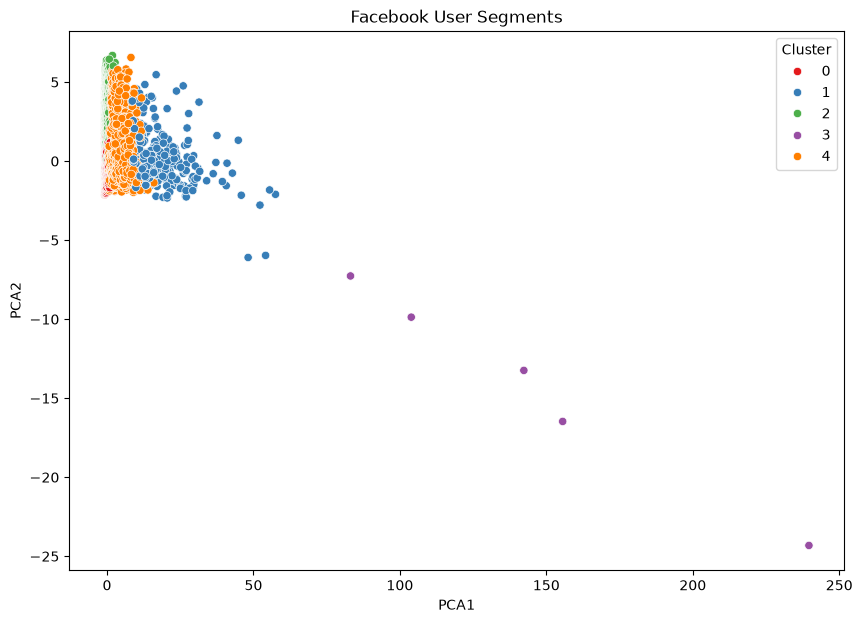

In [30]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1'
)

plt.title('Facebook User Segments')
plt.show()

### Silhouette Score

In [31]:
score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score:",
    round(score,3)
)

Silhouette Score: 0.268


### Cluster Aalysis

In [32]:
cluster_summary = df.groupby(
    'Cluster'
)[features].mean()

print(cluster_summary)

               age       tenure  friend_count  friendships_initiated  \
Cluster                                                                
0        29.835872   362.173631    121.156226              72.996704   
1        32.619580   600.441958    996.335664             466.083916   
2        69.920249  1221.664467    177.127482              89.542549   
3        20.600000   471.400000   2286.600000             485.800000   
4        29.890988   696.457214   1437.005462             715.869822   

               likes  likes_received  mobile_likes  mobile_likes_received  \
Cluster                                                                     
0          81.611379       58.334092     61.040062              34.662877   
1        5135.640559     4471.837762   3319.425175            2617.593007   
2         147.258237      104.980799     83.556840              56.744600   
3        3063.600000   156005.000000   2029.600000           95291.800000   
4         659.790168      868.736

## Create Pipeline

In [33]:
import pandas as pd

df = pd.read_csv("pseudo_facebook.csv")

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['tenure'] = df['tenure'].fillna(df['tenure'].median())

features = [
    'age',
    'tenure',
    'friend_count',
    'friendships_initiated',
    'likes',
    'likes_received',
    'mobile_likes',
    'mobile_likes_received',
    'www_likes',
    'www_likes_received'
]

X = df[features]

print(X.shape)

(99003, 10)


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Create Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42, n_init=10))
])

# Train Pipeline
pipeline.fit(X)

# Save Pipeline
joblib.dump(pipeline, 'facebook_clustering_pipeline.pkl')

print("Pipeline Saved Successfully!")

Pipeline Saved Successfully!


In [37]:
sample_user = [[
    25,
    500,
    200,
    100,
    500,
    300,
    200,
    150,
    250,
    100
]]

prediction = pipeline.predict(sample_user)

print("Predicted Cluster:", prediction[0])

Predicted Cluster: 0


### 🎯 Project Conclusion

The Facebook User Segmentation AI project successfully analyzed user behavior data and grouped users into meaningful segments using K-Means Clustering. Through data preprocessing, exploratory data analysis (EDA), feature scaling, and clustering techniques, hidden patterns in user engagement were identified.

The Elbow Method determined the optimal number of clusters, while PCA was used for dimensionality reduction and visualization of user groups. A machine learning pipeline was built using StandardScaler and K-Means, enabling consistent preprocessing and real-time predictions.

The final solution was deployed as an interactive Streamlit web application, allowing users to input engagement metrics and instantly receive a predicted user segment along with behavioral insights.

Key Achievements

1. ✅ Cleaned and prepared real-world social media data
2. ✅ Performed comprehensive EDA and correlation analysis
3. ✅ Identified optimal clusters using the Elbow Method
4. ✅ Built an end-to-end Scikit-Learn Pipeline
5. ✅ Applied PCA for cluster visualization
6. ✅ Developed an interactive Streamlit dashboard
7. ✅ Enabled real-time user segmentation and prediction

Business Impact

This segmentation system helps social media platforms better understand user behavior, improve personalization, optimize marketing campaigns, increase user engagement, and support data-driven decision-making.

Technologies Used
Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn
K-Means Clustering
PCA
Joblib
Streamlit
Final Outcome

The project demonstrates how machine learning can transform raw social media data into actionable user insights, creating a scalable and intelligent user segmentation system for modern digital platforms.

🚀 Result: Successfully built and deployed an AI-powered Facebook User Segmentation application capable of classifying users into distinct behavioral groups based on their activity and engagement patterns.